# 50.3 · Containers and deployment boundaries

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain containers and deployment boundaries using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[49 · Model Optimization](../../49-model-optimization/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Deployment wraps model behavior in a stable interface. Input validation, preprocessing, versioned outputs and useful failure responses are part of correctness. A local demo becomes a service only when its state, storage and operating assumptions are explicit.

## 2. Intuition

A container packages the application but does not automatically supply authentication, TLS, quotas or scalable storage. Run the teaching service on localhost first. FastAPI suits APIs; Streamlit and Gradio can provide quick local model interfaces. A production service needs deployment-specific load tests, monitoring and a migration plan for stateful workers.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 50
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
L_{end}=L_{decode}+L_{pre}+L_{model}+L_{post}+L_{transport}
$$

Lend is end-to-end latency and the remaining terms are decode, preprocessing, inference, postprocessing and transport times. Components 2,3,10,2,5 milliseconds sum to 22 ms. Server model time alone is only one component.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
components_ms = np.array([2.0, 3.0, 10.0, 2.0, 5.0])
end_to_end_ms = components_ms.sum()
assert end_to_end_ms == 22
print(end_to_end_ms)

22.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The capstone factory constructs an API, per-session engine and SQLite event store. Tests send real request payloads without opening a public network listener.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def deployment(lesson=0, seed=42, amount=1.0):
    try:
        from fastapi.testclient import TestClient

        from cvzero.platform.app import create_app
    except ImportError as exc:
        raise ImportError('Install API dependencies: python -m pip install -e ".[api]"') from exc
    image = np.zeros((96, 128, 3), np.uint8)
    cv2.circle(image, (32, 40), 18, (235, 70, 60), -1)
    cv2.rectangle(image, (78, 45), (111, 78), (40, 220, 100), -1)
    _, encoded = cv2.imencode(".png", image[..., ::-1])
    with tempfile.TemporaryDirectory() as folder:
        with TestClient(create_app(Path(folder) / "events.sqlite")) as client:
            sid = client.post("/sessions").json()["session_id"]
            payload = {"frame_id": 0, "image_base64": base64.b64encode(encoded).decode()}
            response = client.post(f"/sessions/{sid}/frames", json=payload)
            response.raise_for_status()
            report = response.json()
            duplicate = client.post(f"/sessions/{sid}/frames", json=payload)
            history = client.get(f"/sessions/{sid}/history").json()["events"]
    annotated = cv2.imdecode(
        np.frombuffer(base64.b64decode(report["image_base64"]), np.uint8), cv2.IMREAD_COLOR
    )[..., ::-1]
    return Result(
        "50 · Inference API contract and persistence",
        {"RGB request": image, "API response overlay": annotated},
        metrics={
            "http_status": response.status_code,
            "duplicate_frame_status": duplicate.status_code,
            "persisted_frames": len(history),
            "detections": report["count"],
            "engine_latency_ms": report["latency_ms"],
        },
        notes="Actual FastAPI request handling and SQLite writes through an in-process HTTP client. No public server is launched. Network latency, authentication and concurrent load are not measured here.",
    )

{
  "http_status": 200,
  "duplicate_frame_status": 409,
  "persisted_frames": 1,
  "detections": 2,
  "engine_latency_ms": 1.2650260000555136
}
Actual FastAPI request handling and SQLite writes through an in-process HTTP client. No public server is launched. Network latency, authentication and concurrent load are not measured here.


/workspace/scratch/090df009883a/.venv-build/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/engineering.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.engineering import queue_simulation

display(Code(inspect.getsource(queue_simulation), language="python"))

def queue_simulation(arrivals, service_seconds, capacity=2):
    """Discrete-event latest-frame queue. Returns completed latencies and drops."""
    if service_seconds <= 0 or capacity < 1:
        raise ValueError("Positive service time and capacity required.")
    waiting = []
    completed = []
    dropped = 0
    busy_until = None
    active = None
    for arrival in arrivals:
        while busy_until is not None and busy_until <= arrival:
            completed.append(busy_until - active)
            if waiting:
                active = waiting.pop(0)
                busy_until += service_seconds
            else:
                busy_until = None
                active = None
        if busy_until is None:
            active = float(arrival)
            busy_until = active + service_seconds
        else:
            if len(waiting) >= capacity:
                waiting.pop(0)
                dropped += 1
            waiting.append(float(arrival))
    while busy_until is not None:
        completed.append(busy_until - active)
        if waiting:
            active = waiting.pop(0)
            busy_until += service_seconds
        else:
            busy_until = None
    return np.array(completed), dropped

## 8. Experiment

Send invalid images, duplicate IDs and oversized dimensions. Verify status codes and that failed requests do not create stored events.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "http_status": 200,
    "duplicate_frame_status": 409,
    "persisted_frames": 1,
    "detections": 2,
    "engine_latency_ms": 1.2650260000555136
  },
  "second_seed": {
    "http_status": 200,
    "duplicate_frame_status": 409,
    "persisted_frames": 1,
    "detections": 2,
    "engine_latency_ms": 0.5649310000990226
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

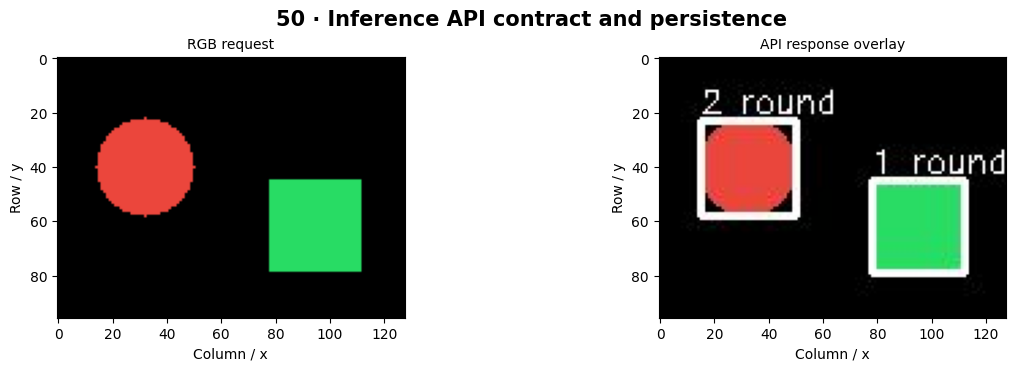

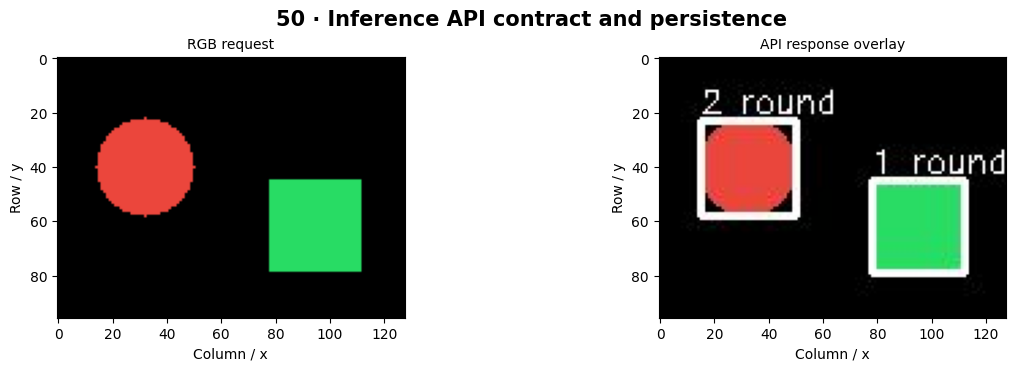

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Production Vision API**. Serve a versioned model and validate requests and predictions. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

In-memory session state is not shared across server processes. Multiple workers need a deliberate state partitioning or external-state design.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Send invalid images, duplicate IDs and oversized dimensions. Verify status codes and that failed requests do not create stored events.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Deploy the local service in a container, add a versioned model artifact and document authentication, scaling and rollback requirements before public exposure.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A container packages the application but does not automatically supply authentication, TLS, quotas or scalable storage. Run the teaching service on localhost first. FastAPI suits APIs; Streamlit and Gradio can provide quick local model interfaces. A production service needs deployment-specific load tests, monitoring and a migration plan for stateful workers.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[51 · Edge AI](../../51-edge-ai/README.md)

[Primary reference](https://fastapi.tiangolo.com/tutorial/) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)